In [1]:
%load_ext autoreload
%autoreload 2

# Load libraries and custom functions

In [2]:
import utils as my_utils
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Regrid WOA data and ideal age to Bern3D grid

In [3]:
# Define  the file paths to WOA and ideal age data

# Restructure the ideal age dataset to have proper coordinates and dimension names
file = "/storage/homefs/uh24x373/bgc_bern/optimize_wind_velocity/spinup/bern3d_f90/results/OCIM/115838.nc"
ds_ida = xr.open_dataset(file, decode_times=False)
ds_ida = ds_ida.assign_coords(Depth=("Depth", ds_ida['zt'].values))
ds_ida = ds_ida.assign_coords(Longitude=ds_ida.xt.values, Latitude=ds_ida.yt.values)

# Crate a dictionary with the datasets to be regridded. The key should be the variable name in the files
woa_dir = "/storage/homefs/uh24x373/bgc_bern/WOA2023/"
variables_to_regrid = {
    'p_an': xr.open_dataset(f'{woa_dir}woa23_all_p00_01.nc', decode_times=False),
    'n_an': xr.open_dataset(f'{woa_dir}woa23_all_n00_01.nc', decode_times=False),
    'i_an': xr.open_dataset(f'{woa_dir}woa23_all_i00_01.nc', decode_times=False),
    'o_an': xr.open_dataset(f'{woa_dir}woa23_all_o00_01.nc', decode_times=False),
    's_an': xr.open_dataset(f'{woa_dir}woa23_decav_s00_01.nc', decode_times=False),
    't_an': xr.open_dataset(f'{woa_dir}woa23_decav_t00_01.nc', decode_times=False),
    'ideal_age': ds_ida
}

# Open the existing Bern3D observations file to use as template for regridding
dim_dictionary = {'lon': 'Longitude', 'lat': 'Latitude', 'depth': 'Depth'}
path_bern3d_observations = "/storage/homefs/uh24x373/bgc_bern/wind_tuning/bern3d_f90/input/world_68x46.observations.nc"
template_grid = xr.open_dataset(path_bern3d_observations, decode_times=False)

# Open the existing Bern3D observations file to overwrite with regridded data
new_bern3d = xr.open_dataset(path_bern3d_observations, decode_times=False, engine="netcdf4", format="NETCDF4_CLASSIC")

# Clean encodings to avoid issues when saving to netcdf4-classic
valid_encodings_nc4 = {
    'szip_pixels_per_block', 'endian', 'compression', 'fletcher32',
    'dtype', 'significant_digits', '_FillValue',
    'szip_coding', 'least_significant_digit', 'complevel',
    'zlib', 'chunksizes', 'contiguous', 'quantize_mode', 'shuffle'
}
encoding = my_utils.clean_encodings(new_bern3d, valid_encodings_nc4)

# Craate a mapping between Bern3D variable names and WOA/ideal age variable names
bern3d_variables = {
    'p_an': 'po4',
    'n_an': 'no3',
    'i_an': 'sio',
    'o_an': 'o2',
    's_an': 'salt',
    't_an': 'temp',
    'ideal_age': 'ida'
}

# Define the attributes for each variable
attributes = {'p_an': {'units': 'mmol/m3', 'long_name': 'WOA23 Phosphate', 'standard_name': 'PO4'},
              'n_an': {'units': 'mmol/m3', 'long_name': 'WOA23 Nitrate', 'standard_name': 'NO3'},
              'i_an': {'units': 'mmol/m3', 'long_name': 'WOA23 Silicate', 'standard_name': 'SiO'},
              'o_an': {'units': 'mmol/m3', 'long_name': 'WOA23 Oxygen', 'standard_name': 'O2'},
              's_an': {'units': 'psu', 'long_name': 'WOA23 Salinity', 'standard_name': 'Salinity'},
              't_an': {'units': 'deg C', 'long_name': 'WOA23 Temperature', 'standard_name': 'Temperature'},
              'ideal_age': {'units': 'years', 'long_name': 'OCIM ideal age', 'standard_name': 'IDA'},
             }

# Regrid each variable and assign to the new Bern3D dataset
for key, value in variables_to_regrid.items():

    ds_tmp = my_utils.regrid_to_bern3d(value, key, template_grid, dim_dictionary=dim_dictionary)
    ds_tmp = ds_tmp.assign_attrs(attributes[key])
    new_bern3d[bern3d_variables[key]] = ds_tmp

## Save to netCDF4 classic

In [4]:
new_bern3d.to_netcdf(f'{woa_dir}world_68x46.observations.nc', engine="netcdf4", encoding=encoding, format="NETCDF4_CLASSIC")

# Plot the maps to check how data differs

In [5]:
depth = 0
woa_map = variables_to_regrid['p_an'].p_an.squeeze()[depth,:,:]
bern3d_old = template_grid['po4'][depth,:,:]
bern3d_new = new_bern3d['po4'][depth,:,:]

vmin_vmax = [0,3]

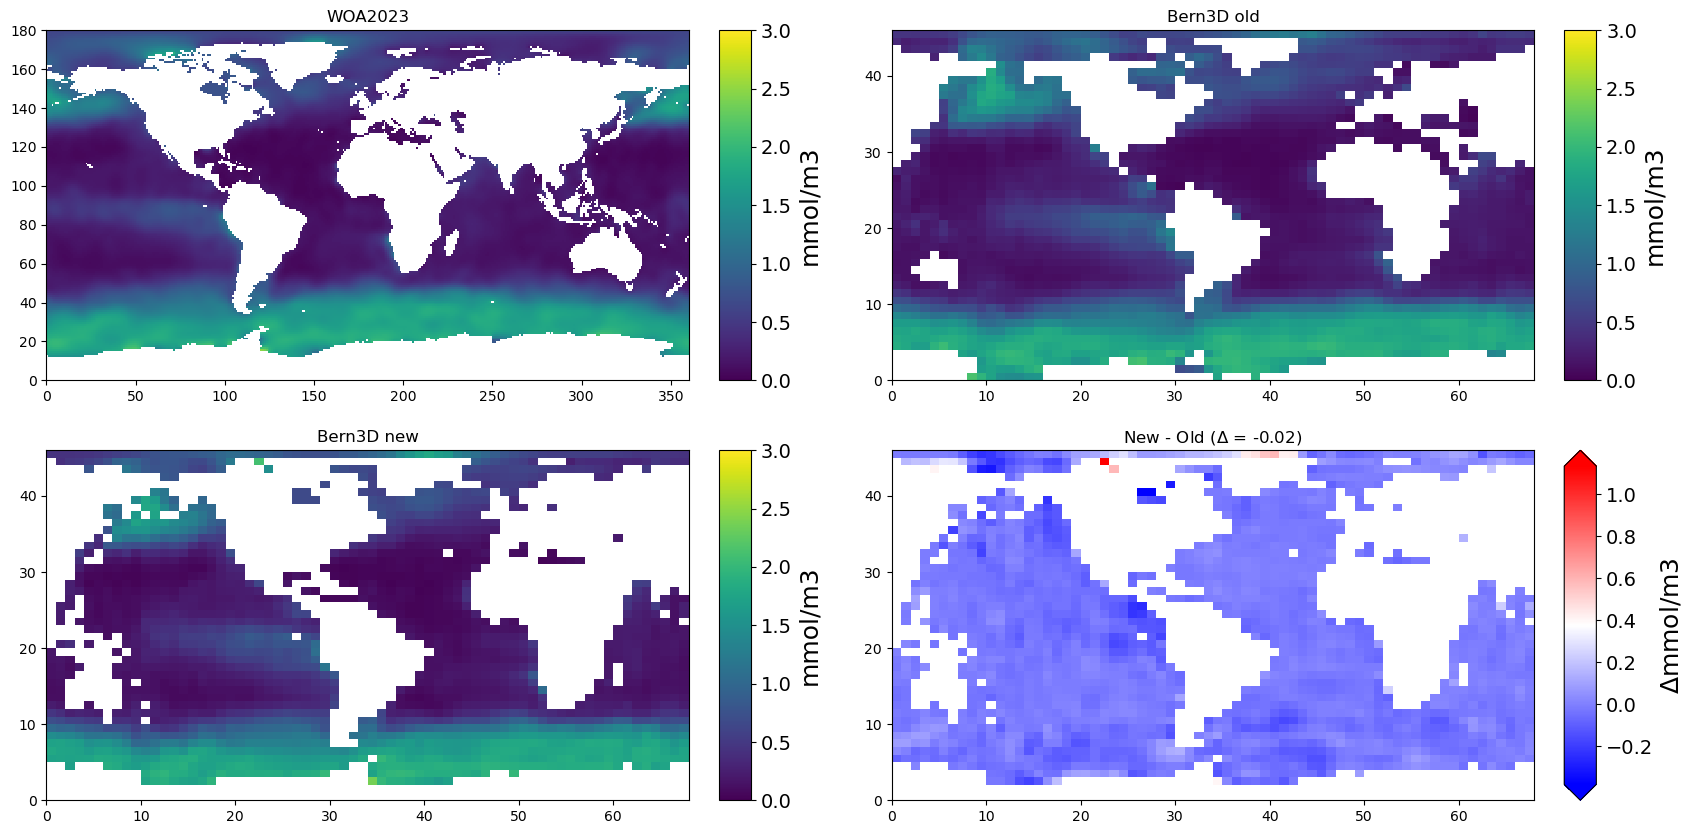

In [6]:
plt.style.use('default')
fig = plt.figure(figsize=(20, 10))
props = dict(shape=[2, 2], fig=fig)
axes = [
    plt.subplot2grid(**props, loc=(0, 0), rowspan=1),
    plt.subplot2grid(**props, loc=(0, 1), rowspan=1),
    plt.subplot2grid(**props, loc=(1, 0), rowspan=1),
    plt.subplot2grid(**props, loc=(1, 1), rowspan=1),
]

ax = axes[0]

contour = ax.pcolormesh(woa_map, shading="auto", cmap='viridis', vmin=vmin_vmax[0], vmax=vmin_vmax[1])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.3)
cb = fig.colorbar(contour, orientation='vertical', cax=cax)
cb.ax.tick_params(labelsize=14)
cb.set_label('mmol/m3', fontsize=18)
ax.set_title('WOA2023')

ax = axes[1]

contour = ax.pcolormesh(bern3d_old, shading="auto", cmap='viridis', vmin=vmin_vmax[0], vmax=vmin_vmax[1])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.3)
cb = fig.colorbar(contour, orientation='vertical', cax=cax)
cb.ax.tick_params(labelsize=14)
cb.set_label('mmol/m3', fontsize=18)
ax.set_title('Bern3D old')

ax = axes[2]

contour = ax.pcolormesh(bern3d_new, shading="auto", cmap='viridis', vmin=vmin_vmax[0], vmax=vmin_vmax[1])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.3)
cb = fig.colorbar(contour, orientation='vertical', cax=cax)
cb.ax.tick_params(labelsize=14)
cb.set_label('mmol/m3', fontsize=18)
ax.set_title('Bern3D new')

ax = axes[3]

data_plot = bern3d_new - bern3d_old
contour = ax.pcolormesh(data_plot, shading="auto", cmap='bwr')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.3)
cb = fig.colorbar(contour, orientation='vertical', cax=cax, extend='both')
cb.ax.tick_params(labelsize=14)
cb.set_label(f'$\Delta$mmol/m3', fontsize=18)
ax.set_title(f"New - Old ($\Delta$ = {np.nanmean(data_plot):.2f})")

plt.show()